# Pocket GraphRAG — Results Visualization
Reads `eval_results.json` from each model folder and generates bar charts.

In [3]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── Load all result files ─────────────────────────────────────────────────────
MODELS = [
    # label, path, color
    # ("DistilBERT\nBaseline",        "checkpoints/distilbert-baseline/results.json",             "#6c757d"),
    # ("Qwen 1.5B\nRAG Gold",         "results/qwen2.5-1.5b-rag-gold/eval_results.json",          "#adb5bd"),
    ("Qwen 0.5B\nGraphRAG Hybrid",  "results/qwen2.5-0.5b-graphrag-hybrid/eval_results.json",   "#74c0fc"),
    # ("Qwen 1.5B\nGraphRAG Gold",    "results/qwen2.5-1.5b-graphrag-gold/eval_results.json",     "#339af0"),
    ("Qwen 1.5B\nGraphRAG Hybrid",  "results/qwen2.5-1.5b-graphrag-hybrid/eval_results.json",   "#1971c2"),
    ("Qwen 3B\nGraphRAG Hybrid",    "results/qwen2.5-3b-graphrag-hybrid/eval_results.json",     "#0c4a6e"),
]

# Key aliases — handle both possible key formats
def get(d, *keys):
    for k in keys:
        if k in d:
            return d[k]
    return None

records = []
for label, path, color in MODELS:
    p = Path(path)
    if not p.exists():
        print(f"MISSING: {path}")
        continue
    with open(p, encoding='utf-8') as f:
        d = json.load(f)
    records.append({
        "label":    label,
        "color":    color,
        "1hop_EM":  get(d, "test_1hop/EM",  "test_1hop_EM")  or 0,
        "2hop_EM":  get(d, "test_2hop/EM",  "test_2hop_EM")  or 0,
        "3hop_EM":  get(d, "test_3hop/EM",  "test_3hop_EM")  or 0,
        "1hop_F1":  get(d, "test_1hop/F1",  "test_1hop_F1")  or 0,
        "2hop_F1":  get(d, "test_2hop/F1",  "test_2hop_F1")  or 0,
        "3hop_F1":  get(d, "test_3hop/F1",  "test_3hop_F1")  or 0,
        "1hop_ms":  get(d, "test_1hop/latency_ms", "test_1hop_latency_ms") or 0,
        "2hop_ms":  get(d, "test_2hop/latency_ms", "test_2hop_latency_ms") or 0,
        "3hop_ms":  get(d, "test_3hop/latency_ms", "test_3hop_latency_ms") or 0,
        "overall_EM": get(d, "overall/EM", "overall_EM") or 0,
        "overall_F1": get(d, "overall/F1", "overall_F1") or 0,
    })
    print(f"Loaded: {label.replace(chr(10), ' ')}")

print(f"\nTotal models loaded: {len(records)}")

Loaded: Qwen 0.5B GraphRAG Hybrid
Loaded: Qwen 1.5B GraphRAG Hybrid
Loaded: Qwen 3B GraphRAG Hybrid

Total models loaded: 3


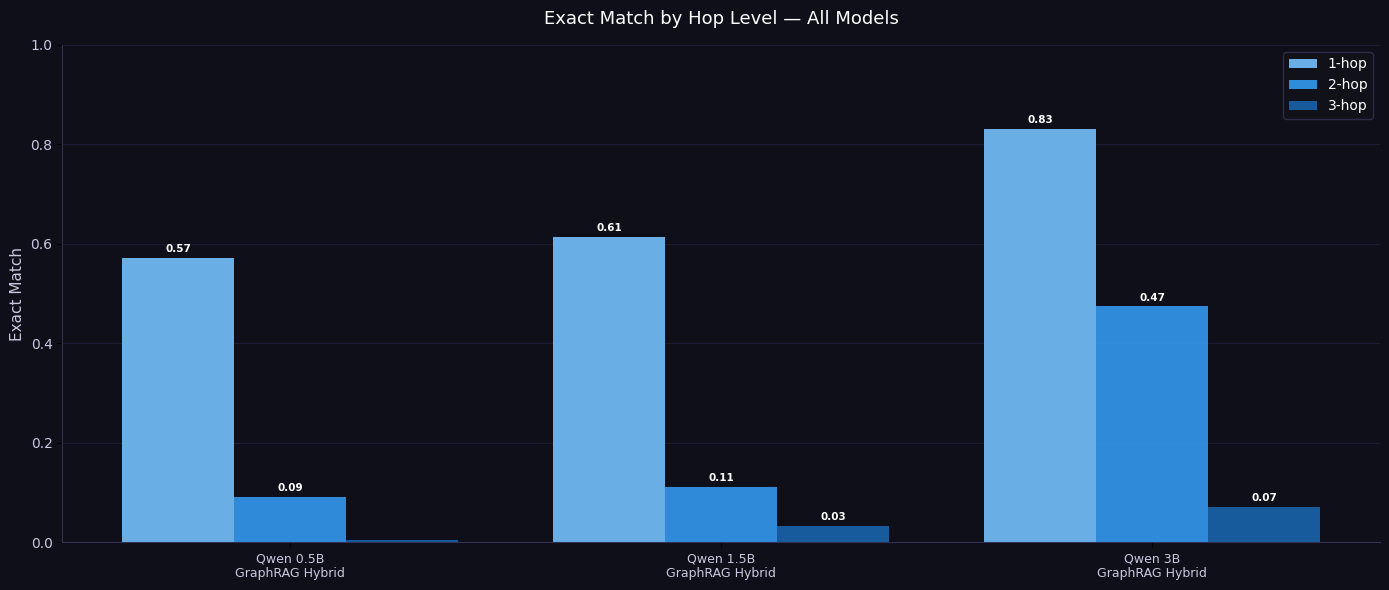

Saved → results/chart_em_by_hop.png


In [4]:
# ── Chart 1: Exact Match per hop (grouped bar chart) ─────────────────────────

labels    = [r["label"] for r in records]
colors    = [r["color"] for r in records]
hop1_em   = [r["1hop_EM"] for r in records]
hop2_em   = [r["2hop_EM"] for r in records]
hop3_em   = [r["3hop_EM"] for r in records]

x = np.arange(len(records))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

b1 = ax.bar(x - width, hop1_em, width, label='1-hop', color='#74c0fc', alpha=0.9)
b2 = ax.bar(x,          hop2_em, width, label='2-hop', color='#339af0', alpha=0.9)
b3 = ax.bar(x + width,  hop3_em, width, label='3-hop', color='#1864ab', alpha=0.9)

# Value labels on bars
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                    f'{h:.2f}', ha='center', va='bottom',
                    fontsize=7.5, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, color='#c8c8e0')
ax.set_ylabel('Exact Match', color='#c8c8e0', fontsize=11)
ax.set_title('Exact Match by Hop Level — All Models', color='white', fontsize=13, pad=15)
ax.set_ylim(0, 1.0)
ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333355')
ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')

plt.tight_layout()
plt.savefig('results/chart_em_by_hop.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Saved → results/chart_em_by_hop.png")

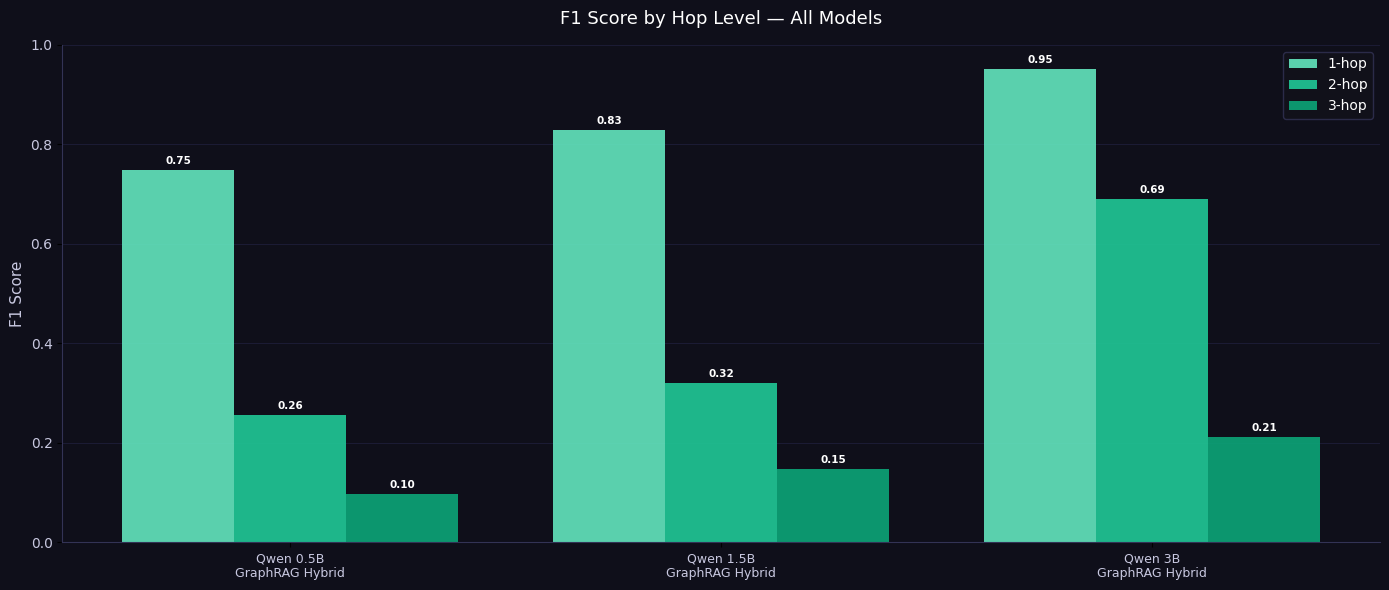

Saved → results/chart_f1_by_hop.png


In [5]:
# ── Chart 2: F1 per hop ───────────────────────────────────────────────────────

hop1_f1 = [r["1hop_F1"] for r in records]
hop2_f1 = [r["2hop_F1"] for r in records]
hop3_f1 = [r["3hop_F1"] for r in records]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

b1 = ax.bar(x - width, hop1_f1, width, label='1-hop', color='#63e6be', alpha=0.9)
b2 = ax.bar(x,          hop2_f1, width, label='2-hop', color='#20c997', alpha=0.9)
b3 = ax.bar(x + width,  hop3_f1, width, label='3-hop', color='#0ca678', alpha=0.9)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                    f'{h:.2f}', ha='center', va='bottom',
                    fontsize=7.5, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, color='#c8c8e0')
ax.set_ylabel('F1 Score', color='#c8c8e0', fontsize=11)
ax.set_title('F1 Score by Hop Level — All Models', color='white', fontsize=13, pad=15)
ax.set_ylim(0, 1.0)
ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333355')
ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')

plt.tight_layout()
plt.savefig('results/chart_f1_by_hop.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Saved → results/chart_f1_by_hop.png")

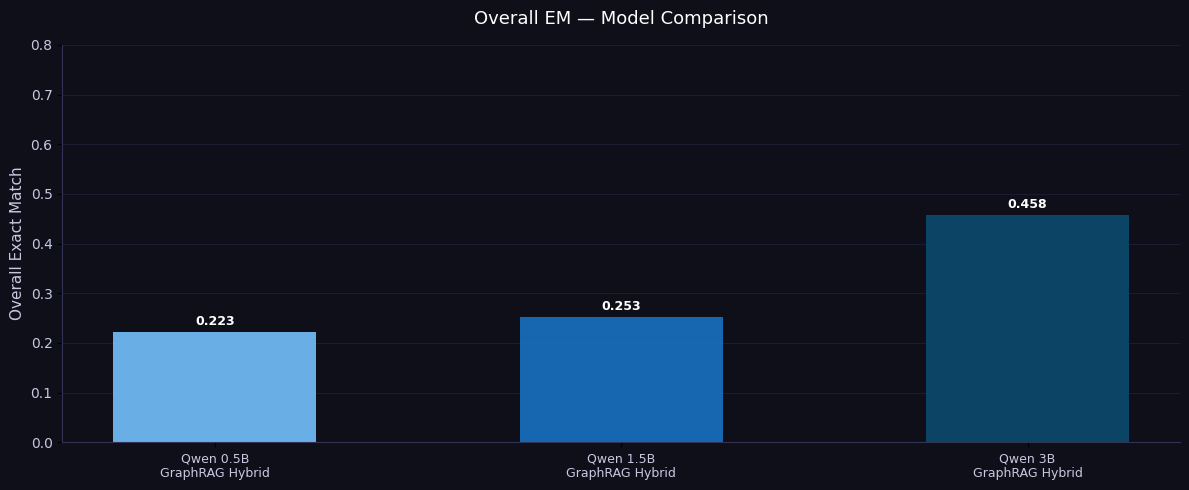

Saved → results/chart_overall_em.png


In [6]:
# ── Chart 3: Overall EM comparison (single bar per model) ────────────────────

overall_em = [r["overall_EM"] for r in records]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

bars = ax.bar(x, overall_em, width=0.5, color=colors, alpha=0.9)

for bar, val in zip(bars, overall_em):
    if val > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, color='#c8c8e0')
ax.set_ylabel('Overall Exact Match', color='#c8c8e0', fontsize=11)
ax.set_title('Overall EM — Model Comparison', color='white', fontsize=13, pad=15)
ax.set_ylim(0, 0.8)
ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333355')
ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('results/chart_overall_em.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Saved → results/chart_overall_em.png")

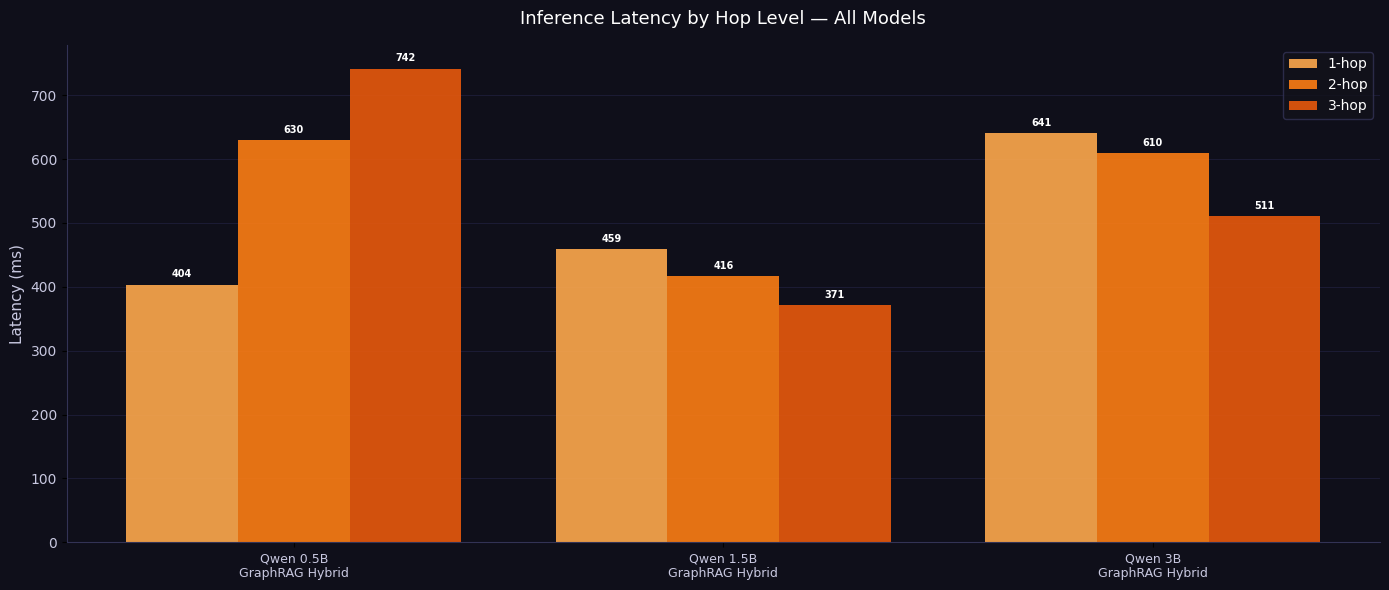

Saved → results/chart_latency.png


In [7]:
# ── Chart 4: Latency comparison ───────────────────────────────────────────────

hop1_ms = [r["1hop_ms"] for r in records]
hop2_ms = [r["2hop_ms"] for r in records]
hop3_ms = [r["3hop_ms"] for r in records]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

b1 = ax.bar(x - width, hop1_ms, width, label='1-hop', color='#ffa94d', alpha=0.9)
b2 = ax.bar(x,          hop2_ms, width, label='2-hop', color='#fd7e14', alpha=0.9)
b3 = ax.bar(x + width,  hop3_ms, width, label='3-hop', color='#e8590c', alpha=0.9)

for bars_g in [b1, b2, b3]:
    for bar in bars_g:
        h = bar.get_height()
        if h > 10:
            ax.text(bar.get_x() + bar.get_width()/2, h + 8,
                    f'{h:.0f}', ha='center', va='bottom',
                    fontsize=7, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, color='#c8c8e0')
ax.set_ylabel('Latency (ms)', color='#c8c8e0', fontsize=11)
ax.set_title('Inference Latency by Hop Level — All Models', color='white', fontsize=13, pad=15)
ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333355')
ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')

plt.tight_layout()
plt.savefig('results/chart_latency.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Saved → results/chart_latency.png")

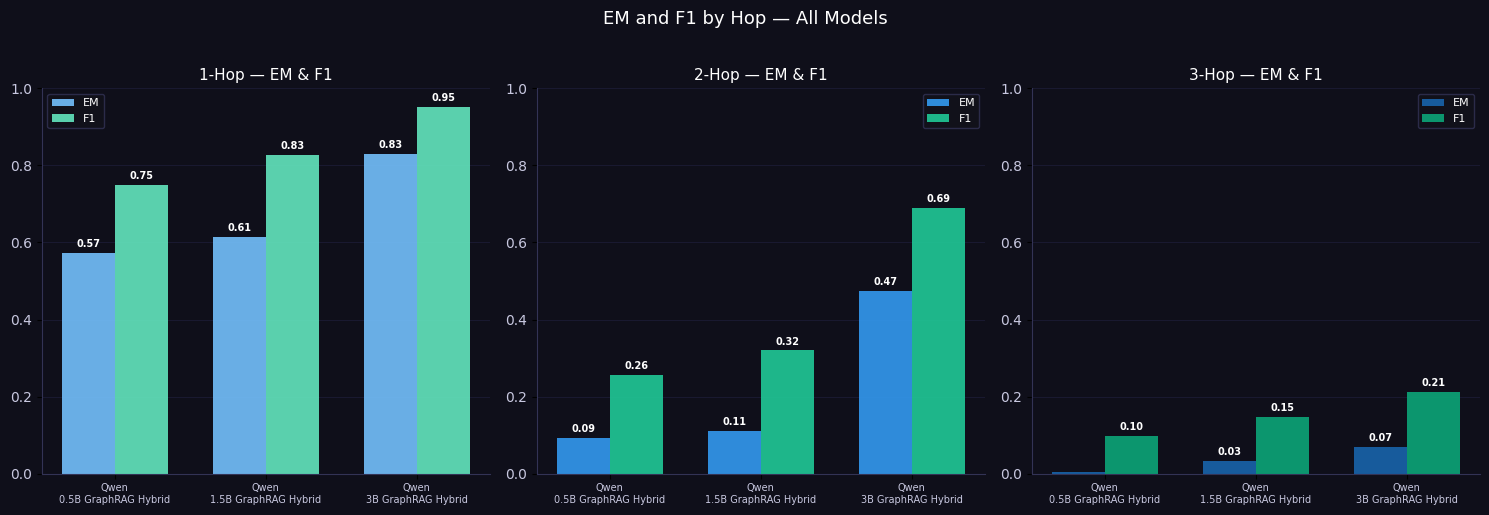

Saved → results/chart_em_f1_per_hop.png


In [8]:
# ── Chart 5: 2-hop EM focus — RAG vs GraphRAG ablation ───────────────────────
# This is your headline finding

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f1a')

short_labels = [r["label"].replace('\n', ' ') for r in records]

for ax, (hop, key_em, key_f1, title, color_em, color_f1) in zip(axes, [
    (1, "1hop_EM", "1hop_F1", "1-Hop",  "#74c0fc", "#63e6be"),
    (2, "2hop_EM", "2hop_F1", "2-Hop",  "#339af0", "#20c997"),
    (3, "3hop_EM", "3hop_F1", "3-Hop",  "#1864ab", "#0ca678"),
]):
    em_vals = [r[key_em] for r in records]
    f1_vals = [r[key_f1] for r in records]
    xi = np.arange(len(records))
    w  = 0.35

    ax.set_facecolor('#0f0f1a')
    b_em = ax.bar(xi - w/2, em_vals, w, label='EM',  color=color_em, alpha=0.9)
    b_f1 = ax.bar(xi + w/2, f1_vals, w, label='F1',  color=color_f1, alpha=0.9)

    for bar in list(b_em) + list(b_f1):
        h = bar.get_height()
        if h > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom',
                    fontsize=7, color='white', fontweight='bold')

    ax.set_xticks(xi)
    ax.set_xticklabels([l.split(' ')[0] + '\n' + ' '.join(l.split(' ')[1:]) for l in short_labels],
                       fontsize=7, color='#c8c8e0')
    ax.set_title(f'{title} — EM & F1', color='white', fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, facecolor='#12121a', edgecolor='#333355', labelcolor='white')

fig.suptitle('EM and F1 by Hop — All Models', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/chart_em_f1_per_hop.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Saved → results/chart_em_f1_per_hop.png")

In [9]:
# ── Print full summary table ───────────────────────────────────────────────────

print(f"{'Model':<30} {'1h-EM':>6} {'2h-EM':>6} {'3h-EM':>6} {'Ovr-EM':>7} {'1h-F1':>6} {'2h-F1':>6} {'3h-F1':>6}")
print("-" * 80)
for r in records:
    name = r['label'].replace('\n', ' ')
    print(
        f"{name:<30} "
        f"{r['1hop_EM']:>6.3f} "
        f"{r['2hop_EM']:>6.3f} "
        f"{r['3hop_EM']:>6.3f} "
        f"{r['overall_EM']:>7.3f} "
        f"{r['1hop_F1']:>6.3f} "
        f"{r['2hop_F1']:>6.3f} "
        f"{r['3hop_F1']:>6.3f}"
    )

print("\nCharts saved to results/ folder:")
for f in ['chart_em_by_hop.png', 'chart_f1_by_hop.png',
          'chart_overall_em.png', 'chart_latency.png', 'chart_em_f1_per_hop.png']:
    print(f"  results/{f}")

Model                           1h-EM  2h-EM  3h-EM  Ovr-EM  1h-F1  2h-F1  3h-F1
--------------------------------------------------------------------------------
Qwen 0.5B GraphRAG Hybrid       0.572  0.092  0.004   0.223  0.749  0.256  0.098
Qwen 1.5B GraphRAG Hybrid       0.614  0.112  0.032   0.253  0.828  0.320  0.147
Qwen 3B GraphRAG Hybrid         0.830  0.474  0.070   0.458  0.951  0.691  0.212

Charts saved to results/ folder:
  results/chart_em_by_hop.png
  results/chart_f1_by_hop.png
  results/chart_overall_em.png
  results/chart_latency.png
  results/chart_em_f1_per_hop.png


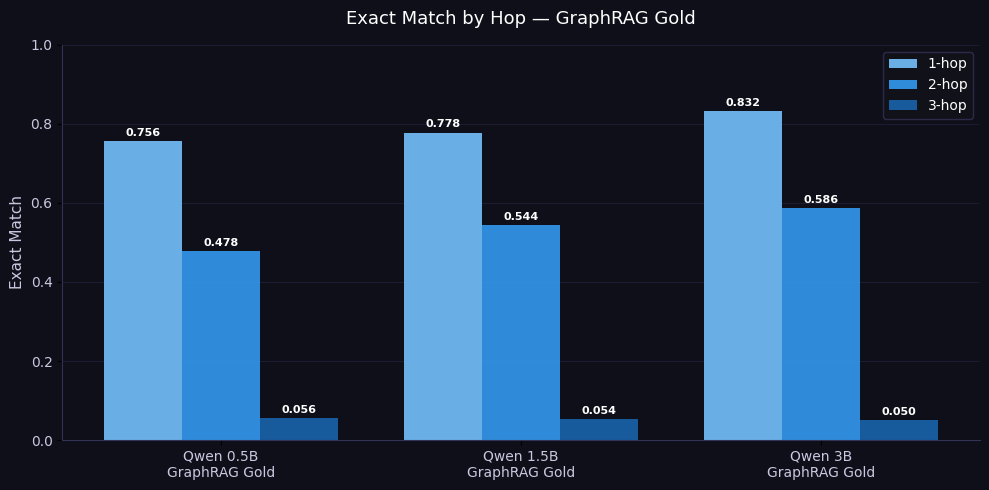

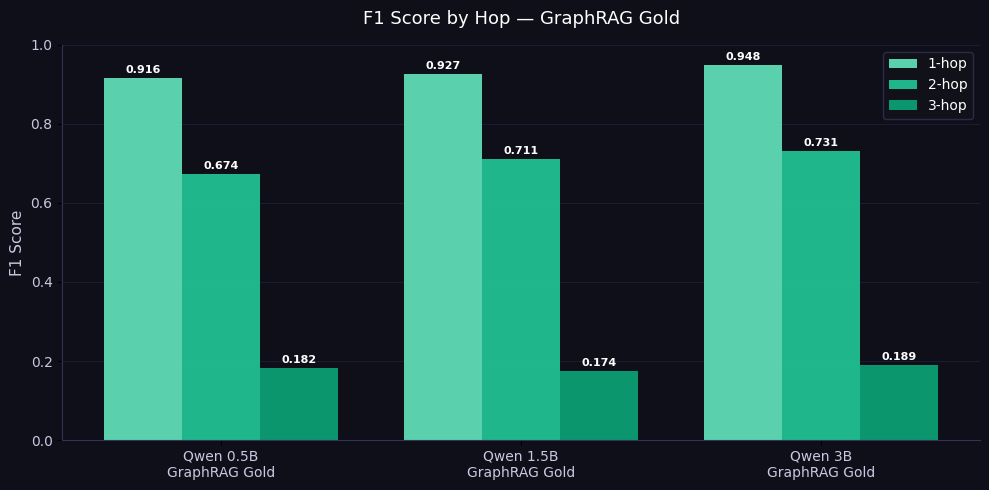

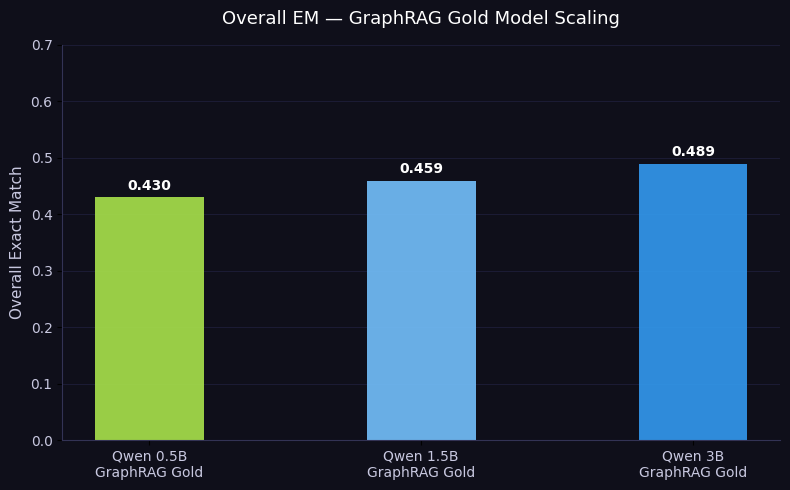

Saved: results/gold_em_by_hop.png
Saved: results/gold_f1_by_hop.png
Saved: results/gold_overall_em.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# GraphRAG Gold results from WandB screenshots
MODELS = [
    # label, 1h_EM, 2h_EM, 3h_EM, overall_EM, 1h_F1, 2h_F1, 3h_F1, color
    ("Qwen 0.5B\nGraphRAG Gold", 0.756, 0.478, 0.056, 0.430, 0.916, 0.674, 0.182, "#a9e34b"),
    ("Qwen 1.5B\nGraphRAG Gold", 0.778, 0.544, 0.054, 0.459, 0.927, 0.711, 0.174, "#74c0fc"),
    ("Qwen 3B\nGraphRAG Gold",   0.832, 0.586, 0.050, 0.489, 0.948, 0.731, 0.189, "#339af0"),
]

labels     = [m[0] for m in MODELS]
colors     = [m[8] for m in MODELS]
hop1_em    = [m[1] for m in MODELS]
hop2_em    = [m[2] for m in MODELS]
hop3_em    = [m[3] for m in MODELS]
overall_em = [m[4] for m in MODELS]
hop1_f1    = [m[5] for m in MODELS]
hop2_f1    = [m[6] for m in MODELS]
hop3_f1    = [m[7] for m in MODELS]

x     = np.arange(len(MODELS))
width = 0.26
BG    = '#0f0f1a'

def style_ax(ax, ylim=1.0):
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10, color='#c8c8e0')
    ax.set_ylim(0, ylim)

def add_labels(ax, bars):
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                    f'{h:.3f}', ha='center', va='bottom',
                    fontsize=8, color='white', fontweight='bold')

# ── Chart 1: EM by hop ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
b1 = ax.bar(x - width, hop1_em, width, label='1-hop', color='#74c0fc', alpha=0.9)
b2 = ax.bar(x,          hop2_em, width, label='2-hop', color='#339af0', alpha=0.9)
b3 = ax.bar(x + width,  hop3_em, width, label='3-hop', color='#1864ab', alpha=0.9)
for b in [b1, b2, b3]: add_labels(ax, b)
style_ax(ax)
ax.set_ylabel('Exact Match', color='#c8c8e0', fontsize=11)
ax.set_title('Exact Match by Hop — GraphRAG Gold', color='white', fontsize=13, pad=15)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')
plt.tight_layout()
plt.savefig('results/gold_em_by_hop.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Chart 2: F1 by hop ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
b1 = ax.bar(x - width, hop1_f1, width, label='1-hop', color='#63e6be', alpha=0.9)
b2 = ax.bar(x,          hop2_f1, width, label='2-hop', color='#20c997', alpha=0.9)
b3 = ax.bar(x + width,  hop3_f1, width, label='3-hop', color='#0ca678', alpha=0.9)
for b in [b1, b2, b3]: add_labels(ax, b)
style_ax(ax)
ax.set_ylabel('F1 Score', color='#c8c8e0', fontsize=11)
ax.set_title('F1 Score by Hop — GraphRAG Gold', color='white', fontsize=13, pad=15)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')
plt.tight_layout()
plt.savefig('results/gold_f1_by_hop.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Chart 3: Overall EM ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)
bars = ax.bar(x, overall_em, width=0.4, color=colors, alpha=0.9)
for bar, val in zip(bars, overall_em):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.008,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=10, color='white', fontweight='bold')
style_ax(ax, ylim=0.7)
ax.set_ylabel('Overall Exact Match', color='#c8c8e0', fontsize=11)
ax.set_title('Overall EM — GraphRAG Gold Model Scaling', color='white', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('results/gold_overall_em.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print("Saved: results/gold_em_by_hop.png")
print("Saved: results/gold_f1_by_hop.png")
print("Saved: results/gold_overall_em.png")

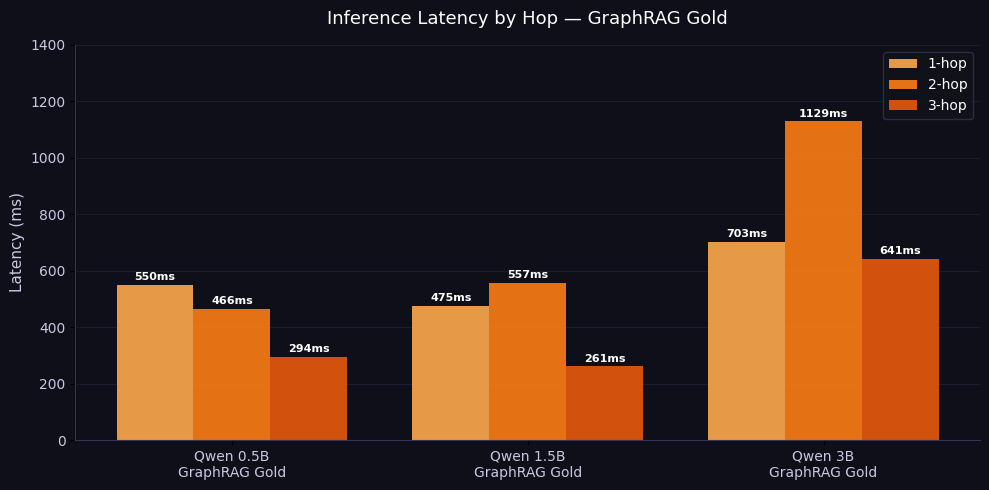

Saved: results/gold_latency.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Latency from WandB screenshots (milliseconds)
MODELS = [
    # label, 1h_ms, 2h_ms, 3h_ms, color
    ("Qwen 0.5B\nGraphRAG Gold", 549.61, 465.51, 294.37, "#a9e34b"),
    ("Qwen 1.5B\nGraphRAG Gold", 474.99, 557.13, 260.97, "#74c0fc"),
    ("Qwen 3B\nGraphRAG Gold",   702.95, 1128.79, 640.65, "#339af0"),
]

labels  = [m[0] for m in MODELS]
colors  = [m[4] for m in MODELS]
hop1_ms = [m[1] for m in MODELS]
hop2_ms = [m[2] for m in MODELS]
hop3_ms = [m[3] for m in MODELS]

x     = np.arange(len(MODELS))
width = 0.26
BG    = '#0f0f1a'

def add_labels(ax, bars):
    for bar in bars:
        h = bar.get_height()
        if h > 5:
            ax.text(bar.get_x() + bar.get_width()/2, h + 10,
                    f'{h:.0f}ms', ha='center', va='bottom',
                    fontsize=8, color='white', fontweight='bold')

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

b1 = ax.bar(x - width, hop1_ms, width, label='1-hop', color='#ffa94d', alpha=0.9)
b2 = ax.bar(x,          hop2_ms, width, label='2-hop', color='#fd7e14', alpha=0.9)
b3 = ax.bar(x + width,  hop3_ms, width, label='3-hop', color='#e8590c', alpha=0.9)

for b in [b1, b2, b3]:
    add_labels(ax, b)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, color='#c8c8e0')
ax.set_ylabel('Latency (ms)', color='#c8c8e0', fontsize=11)
ax.set_title('Inference Latency by Hop — GraphRAG Gold', color='white', fontsize=13, pad=15)
ax.set_ylim(0, 1400)
ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333355')
ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')

plt.tight_layout()
plt.savefig('results/gold_latency.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/gold_latency.png")

Loaded: Qwen 0.5B GraphRAG Hybrid
Loaded: Qwen 1.5B GraphRAG Hybrid
Loaded: Qwen 3B GraphRAG Hybrid


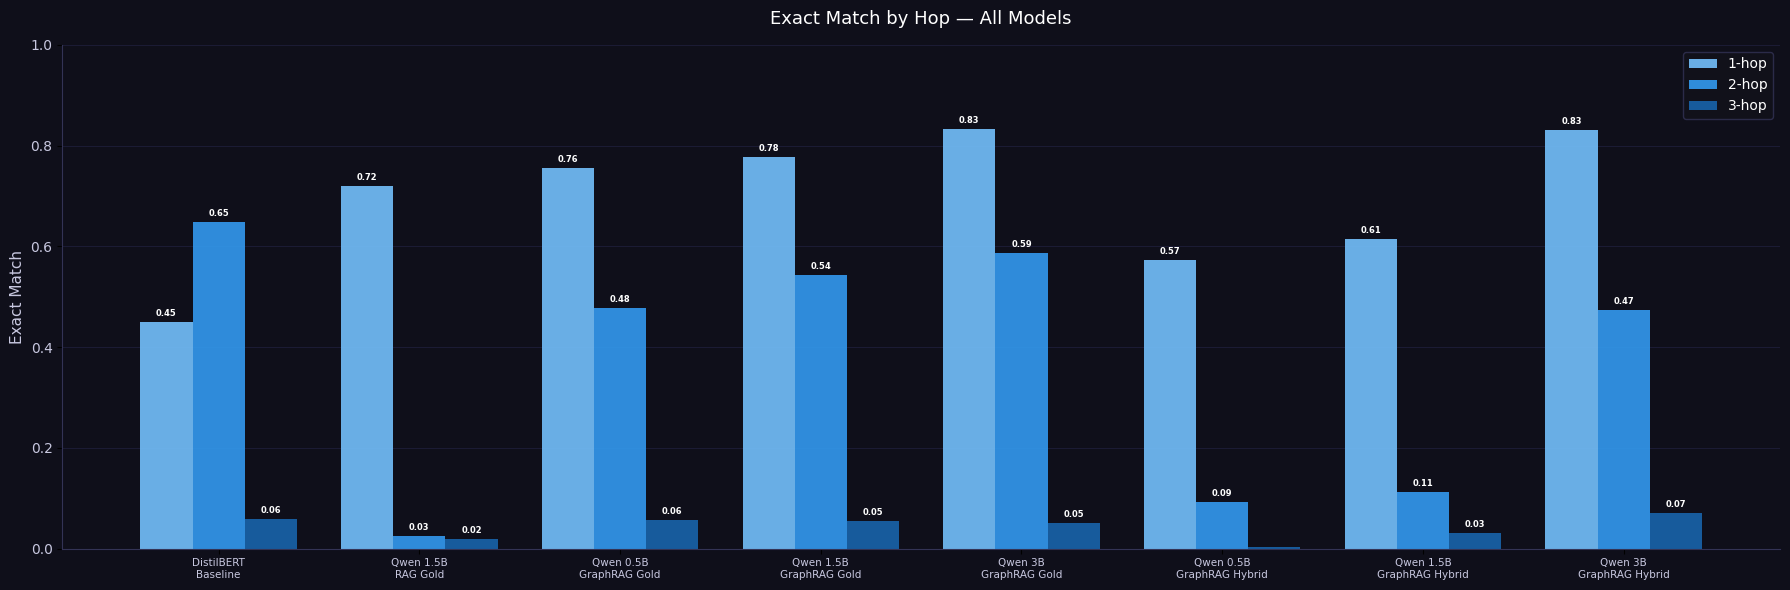

Saved: results/all_em_by_hop.png


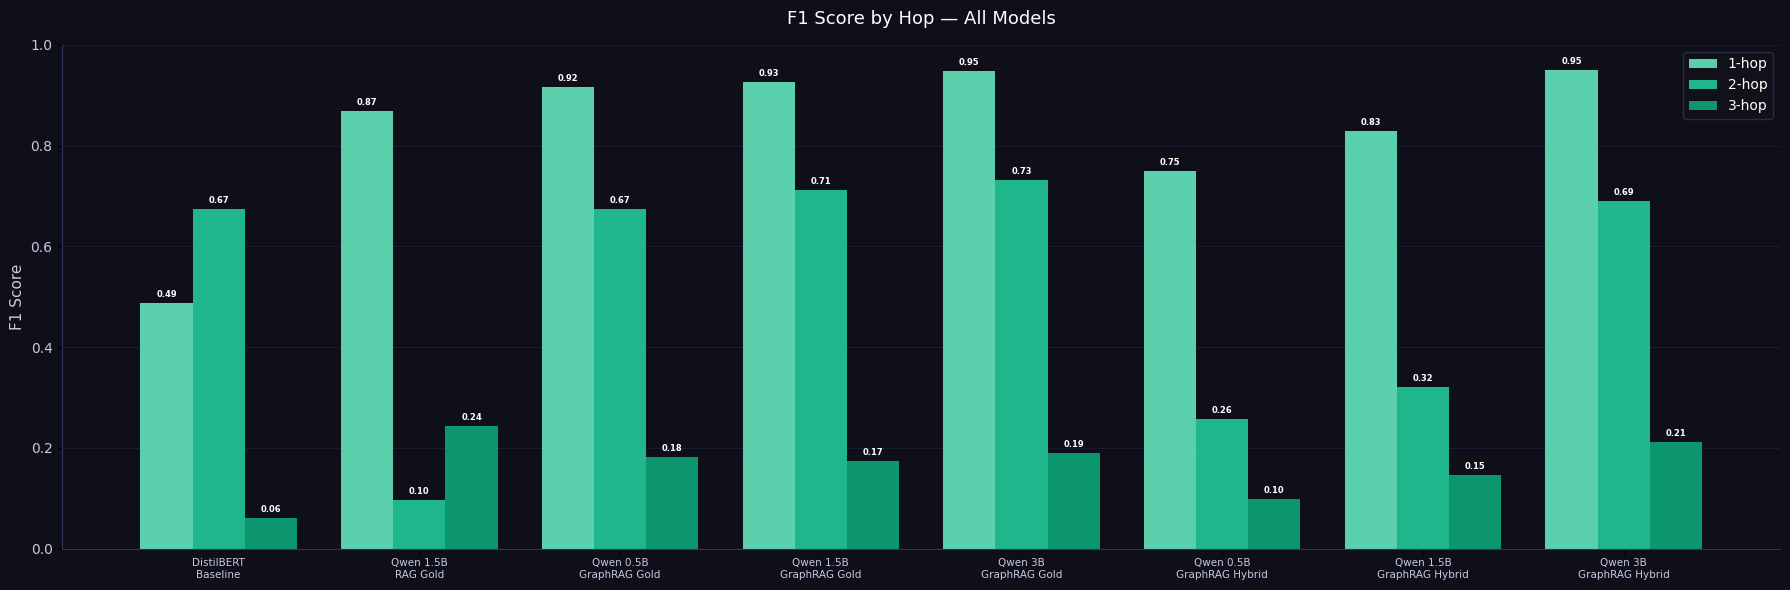

Saved: results/all_f1_by_hop.png


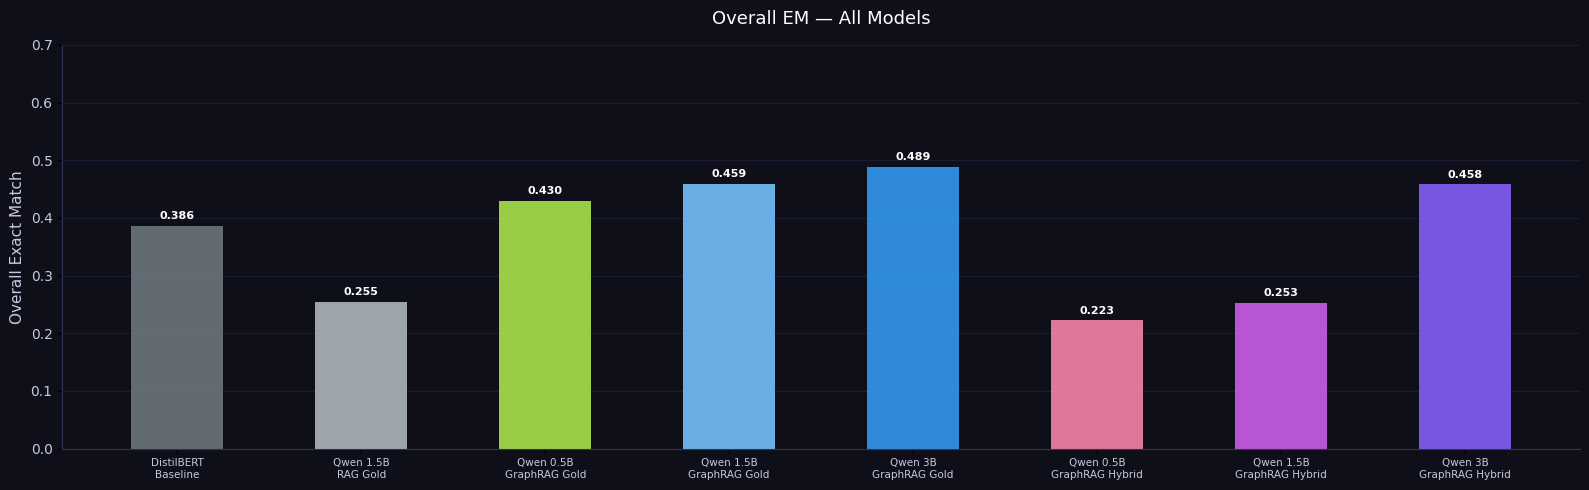

Saved: results/all_overall_em.png


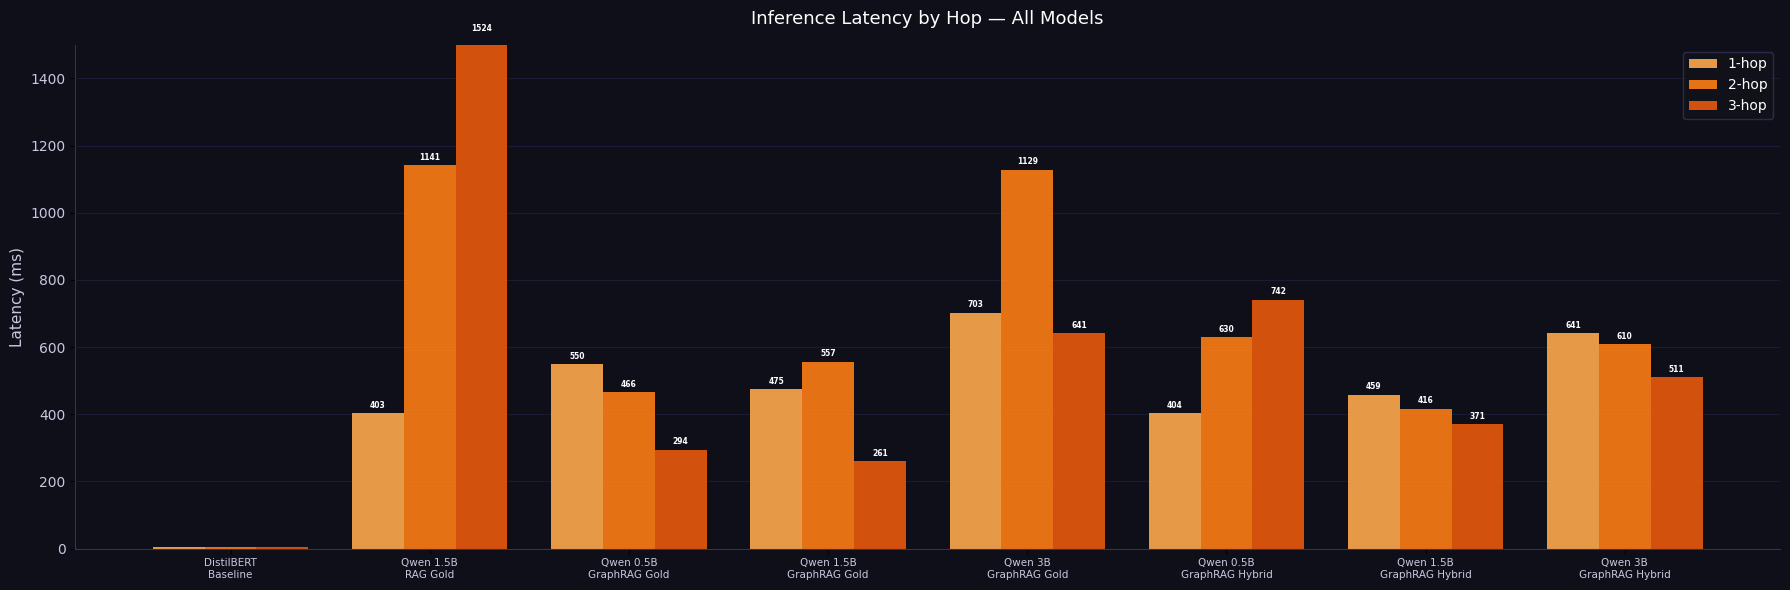

Saved: results/all_latency.png

Model                         1h-EM  2h-EM  3h-EM  Ovr-EM  1h-F1  2h-F1  3h-F1
--------------------------------------------------------------------------------
DistilBERT Baseline           0.449  0.649  0.059   0.386  0.488  0.674  0.061
Qwen 1.5B RAG Gold            0.720  0.025  0.020   0.255  0.869  0.097  0.244
Qwen 0.5B GraphRAG Gold       0.756  0.478  0.056   0.430  0.916  0.674  0.182
Qwen 1.5B GraphRAG Gold       0.778  0.544  0.054   0.459  0.927  0.711  0.174
Qwen 3B GraphRAG Gold         0.832  0.586  0.050   0.489  0.948  0.731  0.189
Qwen 0.5B GraphRAG Hybrid     0.572  0.092  0.004   0.223  0.749  0.256  0.098
Qwen 1.5B GraphRAG Hybrid     0.614  0.112  0.032   0.253  0.828  0.320  0.147
Qwen 3B GraphRAG Hybrid       0.830  0.474  0.070   0.458  0.951  0.691  0.212


In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

BG = '#0f0f1a'

# ── Hardcoded from WandB screenshots (GraphRAG Gold) ─────────────────────────
HARDCODED = [
    # label, 1h_EM, 2h_EM, 3h_EM, overall_EM, 1h_F1, 2h_F1, 3h_F1, 1h_ms, 2h_ms, 3h_ms, color
    ("DistilBERT\nBaseline",       0.449, 0.649, 0.059, 0.386, 0.488, 0.674, 0.061, 5,      6,       6,      "#6c757d"),
    ("Qwen 1.5B\nRAG Gold",        0.720, 0.025, 0.020, 0.255, 0.869, 0.097, 0.244, 403,    1141,    1524,   "#adb5bd"),
    ("Qwen 0.5B\nGraphRAG Gold",   0.756, 0.478, 0.056, 0.430, 0.916, 0.674, 0.182, 549.61, 465.51,  294.37, "#a9e34b"),
    ("Qwen 1.5B\nGraphRAG Gold",   0.778, 0.544, 0.054, 0.459, 0.927, 0.711, 0.174, 474.99, 557.13,  260.97, "#74c0fc"),
    ("Qwen 3B\nGraphRAG Gold",     0.832, 0.586, 0.050, 0.489, 0.948, 0.731, 0.189, 702.95, 1128.79, 640.65, "#339af0"),
]

# ── Load from JSON (GraphRAG Hybrid) ─────────────────────────────────────────
HYBRID_FILES = [
    ("Qwen 0.5B\nGraphRAG Hybrid", "results/qwen2.5-0.5b-graphrag-hybrid/eval_results.json", "#f783ac"),
    ("Qwen 1.5B\nGraphRAG Hybrid", "results/qwen2.5-1.5b-graphrag-hybrid/eval_results.json", "#cc5de8"),
    ("Qwen 3B\nGraphRAG Hybrid",   "results/qwen2.5-3b-graphrag-hybrid/eval_results.json",   "#845ef7"),
]

def get(d, *keys):
    for k in keys:
        if k in d:
            return d[k]
    return 0

loaded = []
for label, path, color in HYBRID_FILES:
    p = Path(path)
    if not p.exists():
        print(f"MISSING: {path}")
        continue
    with open(p, encoding='utf-8') as f:
        d = json.load(f)
    loaded.append((
        label,
        get(d, "test_1hop/EM"),  get(d, "test_2hop/EM"),  get(d, "test_3hop/EM"),
        get(d, "overall/EM"),
        get(d, "test_1hop/F1"),  get(d, "test_2hop/F1"),  get(d, "test_3hop/F1"),
        get(d, "test_1hop/latency_ms"), get(d, "test_2hop/latency_ms"), get(d, "test_3hop/latency_ms"),
        color
    ))
    print(f"Loaded: {label.replace(chr(10),' ')}")

# ── Combine all ───────────────────────────────────────────────────────────────
ALL = HARDCODED + loaded

labels     = [m[0]  for m in ALL]
hop1_em    = [m[1]  for m in ALL]
hop2_em    = [m[2]  for m in ALL]
hop3_em    = [m[3]  for m in ALL]
overall_em = [m[4]  for m in ALL]
hop1_f1    = [m[5]  for m in ALL]
hop2_f1    = [m[6]  for m in ALL]
hop3_f1    = [m[7]  for m in ALL]
hop1_ms    = [m[8]  for m in ALL]
hop2_ms    = [m[9]  for m in ALL]
hop3_ms    = [m[10] for m in ALL]
colors     = [m[11] for m in ALL]

x     = np.arange(len(ALL))
width = 0.26

def style_ax(ax, ylim=1.0):
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5, color='#c8c8e0')
    ax.set_ylim(0, ylim)

def add_labels(ax, bars, fmt='.2f'):
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                    f'{h:{fmt}}', ha='center', va='bottom',
                    fontsize=6, color='white', fontweight='bold')

def add_labels_ms(ax, bars):
    for bar in bars:
        h = bar.get_height()
        if h > 10:
            ax.text(bar.get_x() + bar.get_width()/2, h + 10,
                    f'{h:.0f}', ha='center', va='bottom',
                    fontsize=5.5, color='white', fontweight='bold')

# ── Chart 1: EM by hop ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG)
b1 = ax.bar(x - width, hop1_em, width, label='1-hop', color='#74c0fc', alpha=0.9)
b2 = ax.bar(x,          hop2_em, width, label='2-hop', color='#339af0', alpha=0.9)
b3 = ax.bar(x + width,  hop3_em, width, label='3-hop', color='#1864ab', alpha=0.9)
for b in [b1, b2, b3]: add_labels(ax, b)
style_ax(ax)
ax.set_ylabel('Exact Match', color='#c8c8e0', fontsize=11)
ax.set_title('Exact Match by Hop — All Models', color='white', fontsize=13, pad=15)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')
plt.tight_layout()
plt.savefig('results/all_em_by_hop.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/all_em_by_hop.png")

# ── Chart 2: F1 by hop ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG)
b1 = ax.bar(x - width, hop1_f1, width, label='1-hop', color='#63e6be', alpha=0.9)
b2 = ax.bar(x,          hop2_f1, width, label='2-hop', color='#20c997', alpha=0.9)
b3 = ax.bar(x + width,  hop3_f1, width, label='3-hop', color='#0ca678', alpha=0.9)
for b in [b1, b2, b3]: add_labels(ax, b)
style_ax(ax)
ax.set_ylabel('F1 Score', color='#c8c8e0', fontsize=11)
ax.set_title('F1 Score by Hop — All Models', color='white', fontsize=13, pad=15)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')
plt.tight_layout()
plt.savefig('results/all_f1_by_hop.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/all_f1_by_hop.png")

# ── Chart 3: Overall EM ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(BG)
bars = ax.bar(x, overall_em, width=0.5, color=colors, alpha=0.9)
for bar, val in zip(bars, overall_em):
    if val > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, color='white', fontweight='bold')
style_ax(ax, ylim=0.7)
ax.set_ylabel('Overall Exact Match', color='#c8c8e0', fontsize=11)
ax.set_title('Overall EM — All Models', color='white', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('results/all_overall_em.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/all_overall_em.png")

# ── Chart 4: Latency ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG)
b1 = ax.bar(x - width, hop1_ms, width, label='1-hop', color='#ffa94d', alpha=0.9)
b2 = ax.bar(x,          hop2_ms, width, label='2-hop', color='#fd7e14', alpha=0.9)
b3 = ax.bar(x + width,  hop3_ms, width, label='3-hop', color='#e8590c', alpha=0.9)
for b in [b1, b2, b3]: add_labels_ms(ax, b)
style_ax(ax, ylim=1500)
ax.set_ylabel('Latency (ms)', color='#c8c8e0', fontsize=11)
ax.set_title('Inference Latency by Hop — All Models', color='white', fontsize=13, pad=15)
ax.legend(fontsize=10, facecolor='#12121a', edgecolor='#333355', labelcolor='white')
plt.tight_layout()
plt.savefig('results/all_latency.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/all_latency.png")

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n{'Model':<28} {'1h-EM':>6} {'2h-EM':>6} {'3h-EM':>6} {'Ovr-EM':>7} {'1h-F1':>6} {'2h-F1':>6} {'3h-F1':>6}")
print("-" * 80)
for m in ALL:
    name = m[0].replace('\n', ' ')
    print(f"{name:<28} {m[1]:>6.3f} {m[2]:>6.3f} {m[3]:>6.3f} {m[4]:>7.3f} {m[5]:>6.3f} {m[6]:>6.3f} {m[7]:>6.3f}")

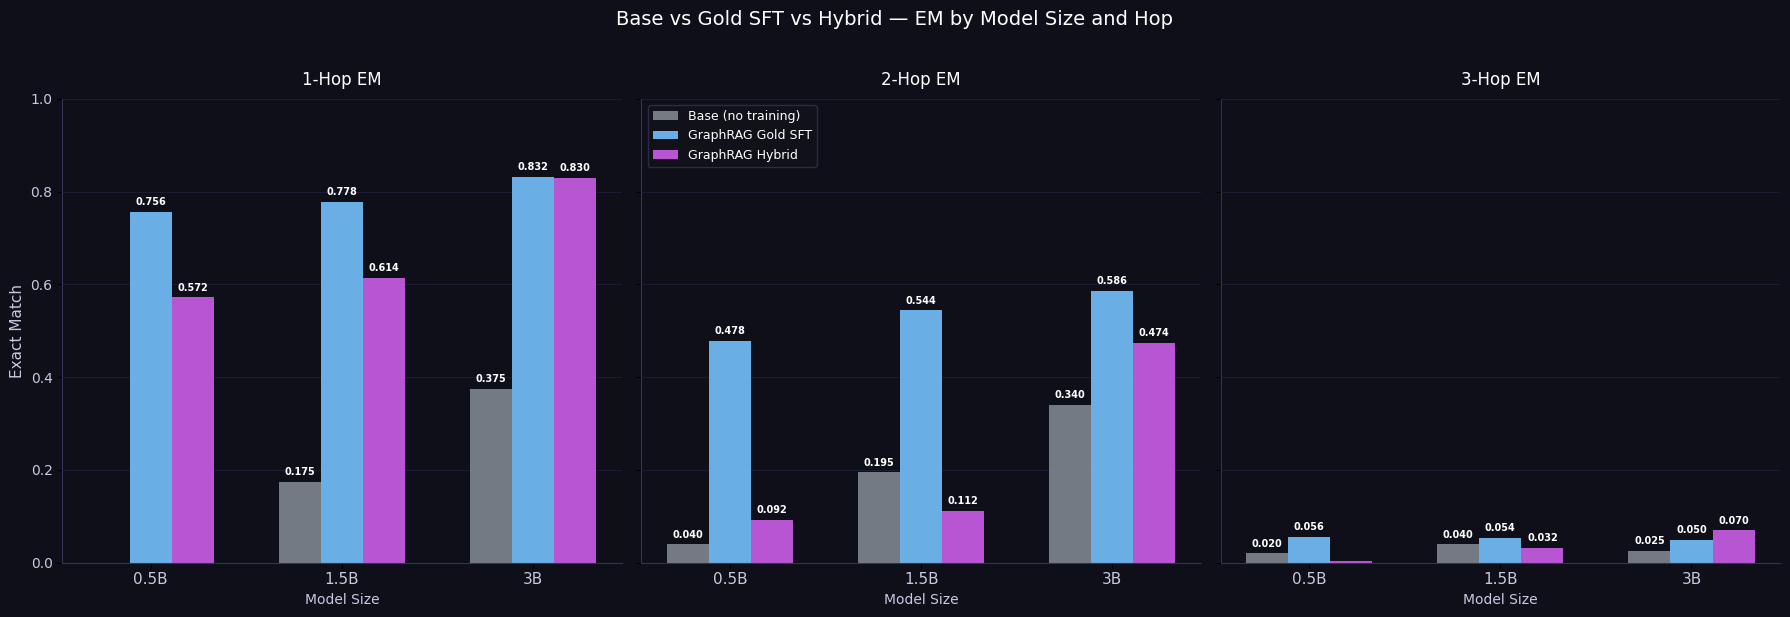

Saved: results/base_vs_finetuned.png


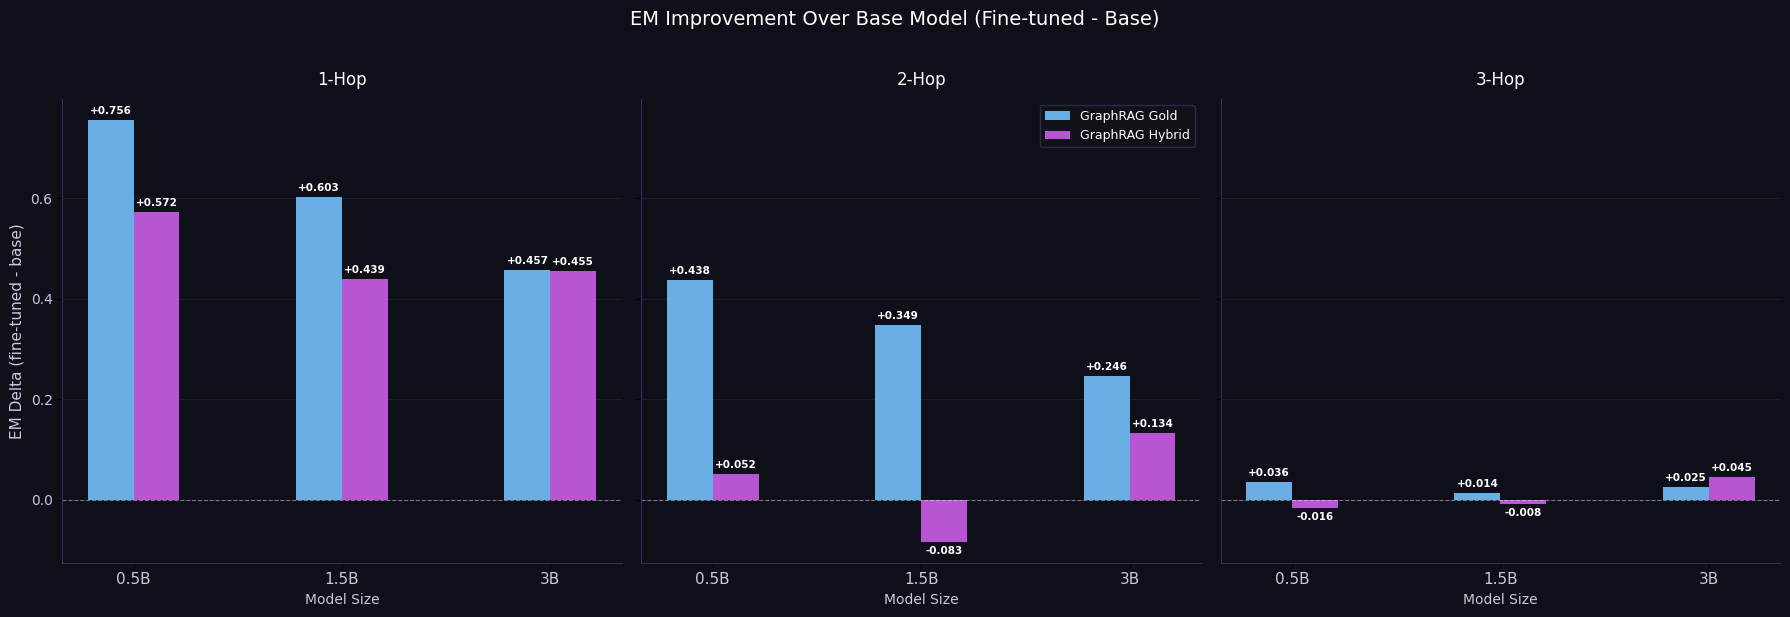

Saved: results/improvement_delta.png


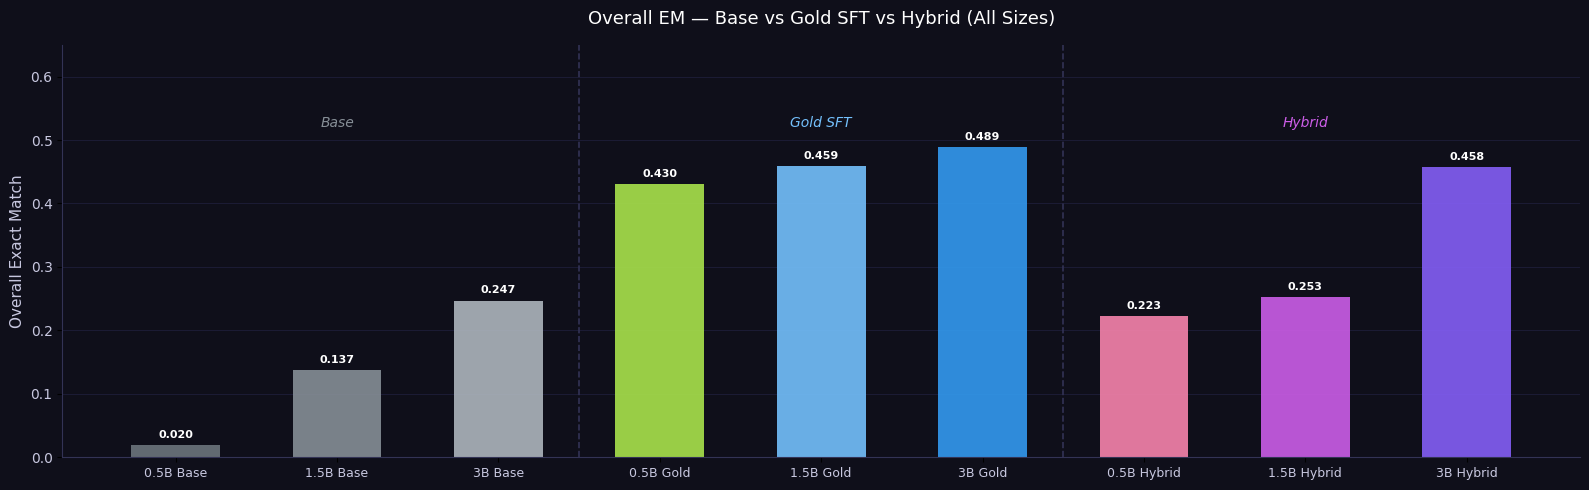

Saved: results/all9_overall_em.png

Model                Type      1h-EM  2h-EM  3h-EM  Ovr-EM
------------------------------------------------------------
0.5B Base            Base      0.000  0.040  0.020   0.020
1.5B Base            Base      0.175  0.195  0.040   0.137
3B Base              Base      0.375  0.340  0.025   0.247

0.5B Gold            Gold      0.756  0.478  0.056   0.430
1.5B Gold            Gold      0.778  0.544  0.054   0.459
3B Gold              Gold      0.832  0.586  0.050   0.489

0.5B Hybrid          Hybrid    0.572  0.092  0.004   0.223
1.5B Hybrid          Hybrid    0.614  0.112  0.032   0.253
3B Hybrid            Hybrid    0.830  0.474  0.070   0.458



In [13]:
import matplotlib.pyplot as plt
import numpy as np

BG = '#0f0f1a'

# ── All data hardcoded ────────────────────────────────────────────────────────
# Format: label, 1h_EM, 2h_EM, 3h_EM, overall_EM, color

BASE = [
    ("0.5B Base",  0.000, 0.040, 0.020, 0.020, "#6c757d"),
    ("1.5B Base",  0.175, 0.195, 0.040, 0.137, "#868e96"),
    ("3B Base",    0.375, 0.340, 0.025, 0.247, "#adb5bd"),
]

GOLD = [
    ("0.5B\nGold", 0.756, 0.478, 0.056, 0.430, "#a9e34b"),
    ("1.5B\nGold", 0.778, 0.544, 0.054, 0.459, "#74c0fc"),
    ("3B\nGold",   0.832, 0.586, 0.050, 0.489, "#339af0"),
]

HYBRID = [
    ("0.5B\nHybrid", 0.572, 0.092, 0.004, 0.223, "#f783ac"),
    ("1.5B\nHybrid", 0.614, 0.112, 0.032, 0.253, "#cc5de8"),
    ("3B\nHybrid",   0.830, 0.474, 0.070, 0.458, "#845ef7"),
]

sizes = ["0.5B", "1.5B", "3B"]
x     = np.arange(3)
w     = 0.22

def style(ax, ylim=1.0):
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes, fontsize=11, color='#c8c8e0')
    ax.set_ylim(0, ylim)

def add_labels(ax, bars):
    for bar in bars:
        h = bar.get_height()
        if h > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom',
                    fontsize=7, color='white', fontweight='bold')

b_1h = [m[1] for m in BASE];   b_2h = [m[2] for m in BASE];   b_3h = [m[3] for m in BASE]
g_1h = [m[1] for m in GOLD];   g_2h = [m[2] for m in GOLD];   g_3h = [m[3] for m in GOLD]
h_1h = [m[1] for m in HYBRID]; h_2h = [m[2] for m in HYBRID]; h_3h = [m[3] for m in HYBRID]

b_col = "#868e96"; g_col = "#74c0fc"; h_col = "#cc5de8"

# ── Chart 1: Base vs Gold vs Hybrid — one panel per hop ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Base vs Gold SFT vs Hybrid — EM by Model Size and Hop',
             color='white', fontsize=14, y=1.02)

for ax, (title, bv, gv, hv) in zip(axes, [
    ("1-Hop EM", b_1h, g_1h, h_1h),
    ("2-Hop EM", b_2h, g_2h, h_2h),
    ("3-Hop EM", b_3h, g_3h, h_3h),
]):
    r1 = ax.bar(x - w, bv, w, label='Base (no training)', color=b_col, alpha=0.85)
    r2 = ax.bar(x,     gv, w, label='GraphRAG Gold SFT',  color=g_col, alpha=0.9)
    r3 = ax.bar(x + w, hv, w, label='GraphRAG Hybrid',    color=h_col, alpha=0.9)
    for b in [r1, r2, r3]: add_labels(ax, b)
    style(ax)
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.set_xlabel('Model Size', color='#c8c8e0', fontsize=10)

axes[0].set_ylabel('Exact Match', color='#c8c8e0', fontsize=11)
axes[1].legend(fontsize=9, facecolor='#12121a', edgecolor='#333355',
               labelcolor='white', loc='upper left')
plt.tight_layout()
plt.savefig('results/base_vs_finetuned.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/base_vs_finetuned.png")

# ── Chart 2: Delta (improvement over base) ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('EM Improvement Over Base Model (Fine-tuned - Base)',
             color='white', fontsize=14, y=1.02)

for ax, (title, bv, gv, hv) in zip(axes, [
    ("1-Hop", b_1h, g_1h, h_1h),
    ("2-Hop", b_2h, g_2h, h_2h),
    ("3-Hop", b_3h, g_3h, h_3h),
]):
    gd = [g - b for g, b in zip(gv, bv)]
    hd = [h - b for h, b in zip(hv, bv)]

    r1 = ax.bar(x - w/2, gd, w, label='GraphRAG Gold',   color=g_col, alpha=0.9)
    r2 = ax.bar(x + w/2, hd, w, label='GraphRAG Hybrid', color=h_col, alpha=0.9)

    for bars in [r1, r2]:
        for bar in bars:
            h_val = bar.get_height()
            offset = 0.008 if h_val >= 0 else -0.028
            ax.text(bar.get_x() + bar.get_width()/2, h_val + offset,
                    f'{h_val:+.3f}', ha='center', va='bottom',
                    fontsize=7.5, color='white', fontweight='bold')

    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes, fontsize=11, color='#c8c8e0')
    ax.axhline(0, color='#ffffff', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.set_xlabel('Model Size', color='#c8c8e0', fontsize=10)

axes[0].set_ylabel('EM Delta (fine-tuned - base)', color='#c8c8e0', fontsize=11)
axes[1].legend(fontsize=9, facecolor='#12121a', edgecolor='#333355', labelcolor='white')
plt.tight_layout()
plt.savefig('results/improvement_delta.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/improvement_delta.png")

# ── Chart 3: Overall EM all 9 models side by side ─────────────────────────────
all_labels = [m[0].replace('\n',' ') for m in BASE + GOLD + HYBRID]
all_em     = [m[4] for m in BASE + GOLD + HYBRID]
all_colors = [m[5] for m in BASE + GOLD + HYBRID]
xi = np.arange(len(all_labels))

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
bars = ax.bar(xi, all_em, width=0.55, color=all_colors, alpha=0.9)
for bar, val in zip(bars, all_em):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.008,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=8, color='white', fontweight='bold')

# Group dividers
for pos in [2.5, 5.5]:
    ax.axvline(pos, color='#333355', linewidth=1.2, linestyle='--')
ax.text(1,   0.52, 'Base', ha='center', color='#868e96', fontsize=10, style='italic')
ax.text(4,   0.52, 'Gold SFT', ha='center', color='#74c0fc', fontsize=10, style='italic')
ax.text(7,   0.52, 'Hybrid', ha='center', color='#cc5de8', fontsize=10, style='italic')

ax.set_xticks(xi)
ax.set_xticklabels(all_labels, fontsize=9, color='#c8c8e0')
ax.set_ylabel('Overall Exact Match', color='#c8c8e0', fontsize=11)
ax.set_title('Overall EM — Base vs Gold SFT vs Hybrid (All Sizes)', color='white', fontsize=13, pad=15)
ax.set_ylim(0, 0.65)
ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333355')
ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('results/all9_overall_em.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/all9_overall_em.png")

# ── Print full table ──────────────────────────────────────────────────────────
print(f"\n{'Model':<20} {'Type':<8} {'1h-EM':>6} {'2h-EM':>6} {'3h-EM':>6} {'Ovr-EM':>7}")
print("-" * 60)
for group, gtype in [(BASE,'Base'), (GOLD,'Gold'), (HYBRID,'Hybrid')]:
    for m in group:
        print(f"{m[0].replace(chr(10),' '):<20} {gtype:<8} {m[1]:>6.3f} {m[2]:>6.3f} {m[3]:>6.3f} {m[4]:>7.3f}")
    print()

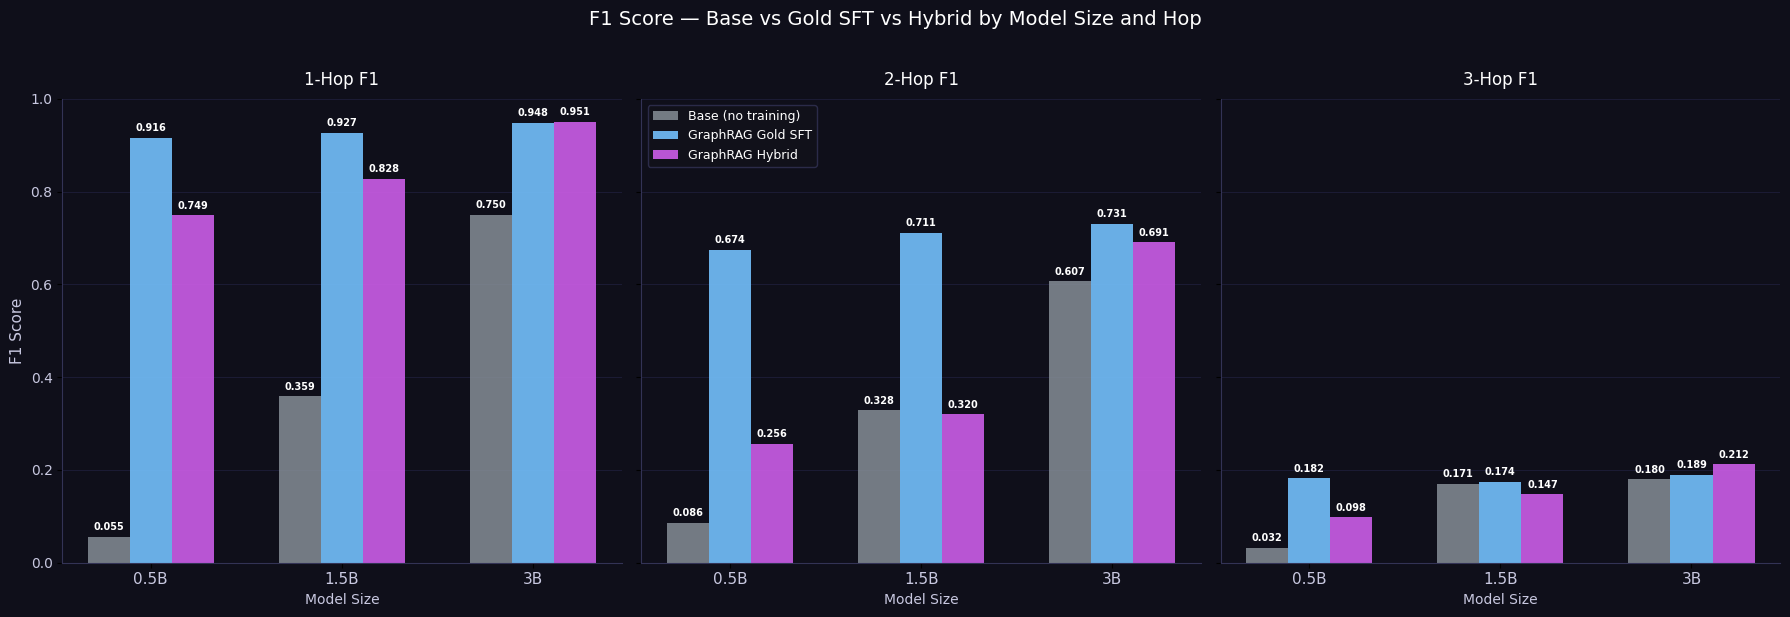

Saved: results/f1_base_vs_finetuned.png


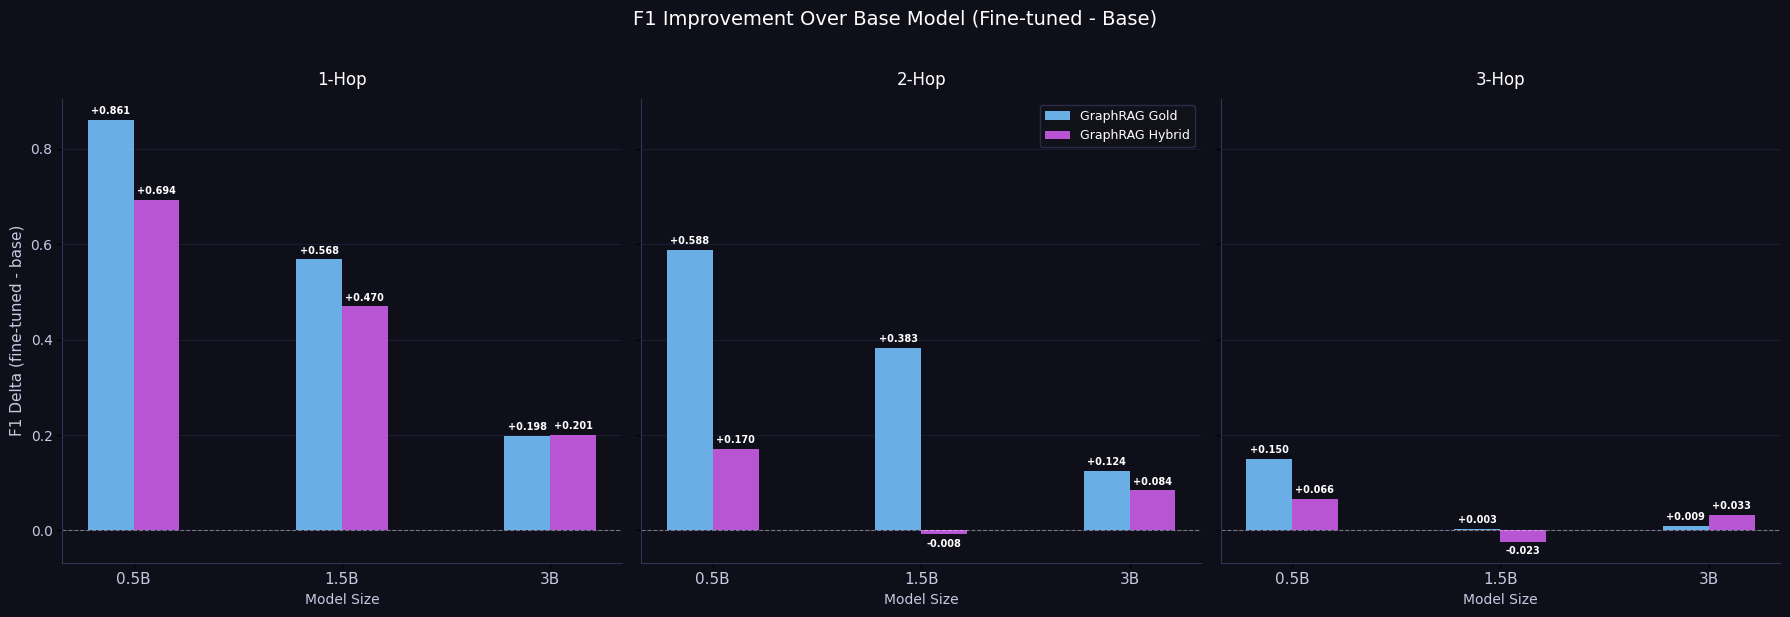

Saved: results/f1_improvement_delta.png


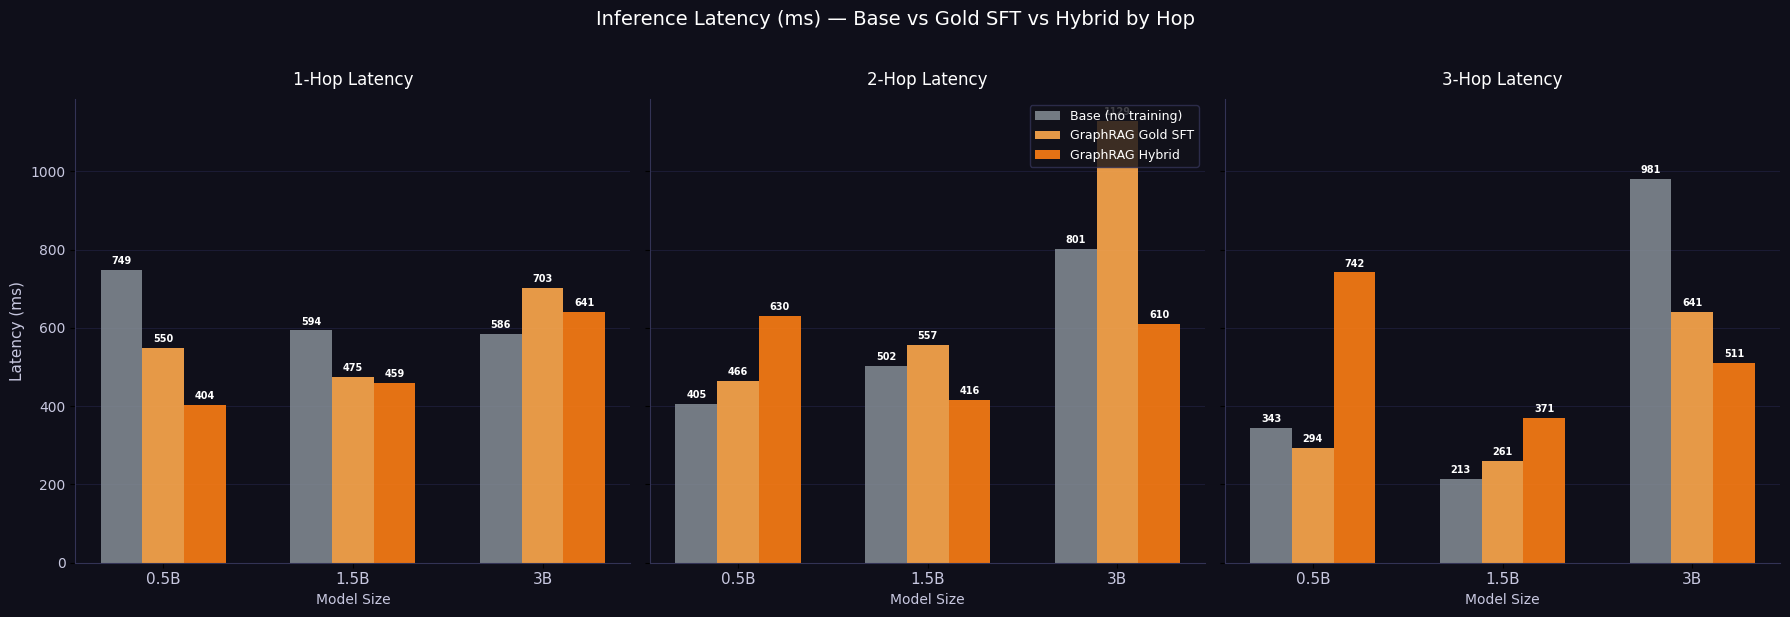

Saved: results/latency_base_vs_finetuned.png

Model                Type       1h-F1   2h-F1   3h-F1    1h-ms    2h-ms    3h-ms
---------------------------------------------------------------------------
0.5B Base            Base       0.055   0.086   0.032    749.1    405.3    343.2
1.5B Base            Base       0.359   0.328   0.171    593.6    501.9    213.2
3B Base              Base       0.750   0.607   0.180    585.5    801.4    981.2

0.5B Gold            Gold       0.916   0.674   0.182    549.6    465.5    294.4
1.5B Gold            Gold       0.927   0.711   0.174    475.0    557.1    261.0
3B Gold              Gold       0.948   0.731   0.189    703.0   1128.8    640.6

0.5B Hybrid          Hybrid     0.749   0.256   0.098    403.6    629.5    741.7
1.5B Hybrid          Hybrid     0.828   0.320   0.147    458.9    416.4    370.9
3B Hybrid            Hybrid     0.951   0.691   0.212    641.3    609.5    510.7



In [14]:
import matplotlib.pyplot as plt
import numpy as np

BG = '#0f0f1a'

# ── All data ──────────────────────────────────────────────────────────────────
# Format: label, 1h_F1, 2h_F1, 3h_F1, 1h_ms, 2h_ms, 3h_ms

BASE = [
    ("0.5B Base",  0.0554, 0.0861, 0.0316, 749.08, 405.28, 343.21),
    ("1.5B Base",  0.3586, 0.3282, 0.1705, 593.61, 501.95, 213.22),
    ("3B Base",    0.7496, 0.6067, 0.1799, 585.55, 801.38, 981.16),
]

GOLD = [
    ("0.5B Gold",  0.916,  0.674,  0.182,  549.61, 465.51, 294.37),
    ("1.5B Gold",  0.927,  0.711,  0.174,  474.99, 557.13, 260.97),
    ("3B Gold",    0.948,  0.731,  0.189,  702.95, 1128.79, 640.65),
]

HYBRID = [
    ("0.5B Hybrid", 0.749,  0.2564, 0.0979, 403.56, 629.50,  741.74),
    ("1.5B Hybrid", 0.8282, 0.320,  0.1471, 458.91, 416.43,  370.92),
    ("3B Hybrid",   0.9508, 0.6906, 0.2125, 641.28, 609.54,  510.68),
]

sizes = ["0.5B", "1.5B", "3B"]
x     = np.arange(3)
w     = 0.22
b_col = "#868e96"; g_col = "#74c0fc"; h_col = "#cc5de8"

b_1f = [m[1] for m in BASE];  b_2f = [m[2] for m in BASE];  b_3f = [m[3] for m in BASE]
g_1f = [m[1] for m in GOLD];  g_2f = [m[2] for m in GOLD];  g_3f = [m[3] for m in GOLD]
h_1f = [m[1] for m in HYBRID];h_2f = [m[2] for m in HYBRID];h_3f = [m[3] for m in HYBRID]

b_1ms = [m[4] for m in BASE];  b_2ms = [m[5] for m in BASE];  b_3ms = [m[6] for m in BASE]
g_1ms = [m[4] for m in GOLD];  g_2ms = [m[5] for m in GOLD];  g_3ms = [m[6] for m in GOLD]
h_1ms = [m[4] for m in HYBRID];h_2ms = [m[5] for m in HYBRID];h_3ms = [m[6] for m in HYBRID]

def style(ax, ylim=1.0):
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes, fontsize=11, color='#c8c8e0')
    ax.set_ylim(0, ylim)

def add_labels(ax, bars, fmt='.3f'):
    for bar in bars:
        h = bar.get_height()
        if h > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:{fmt}}', ha='center', va='bottom',
                    fontsize=7, color='white', fontweight='bold')

def add_labels_ms(ax, bars):
    for bar in bars:
        h = bar.get_height()
        if h > 5:
            ax.text(bar.get_x() + bar.get_width()/2, h + 10,
                    f'{h:.0f}', ha='center', va='bottom',
                    fontsize=7, color='white', fontweight='bold')

# ── Chart 1: F1 by hop — Base vs Gold vs Hybrid ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('F1 Score — Base vs Gold SFT vs Hybrid by Model Size and Hop',
             color='white', fontsize=14, y=1.02)

for ax, (title, bv, gv, hv) in zip(axes, [
    ("1-Hop F1", b_1f, g_1f, h_1f),
    ("2-Hop F1", b_2f, g_2f, h_2f),
    ("3-Hop F1", b_3f, g_3f, h_3f),
]):
    r1 = ax.bar(x - w, bv, w, label='Base (no training)', color=b_col, alpha=0.85)
    r2 = ax.bar(x,     gv, w, label='GraphRAG Gold SFT',  color=g_col, alpha=0.9)
    r3 = ax.bar(x + w, hv, w, label='GraphRAG Hybrid',    color=h_col, alpha=0.9)
    for b in [r1, r2, r3]: add_labels(ax, b)
    style(ax)
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.set_xlabel('Model Size', color='#c8c8e0', fontsize=10)

axes[0].set_ylabel('F1 Score', color='#c8c8e0', fontsize=11)
axes[1].legend(fontsize=9, facecolor='#12121a', edgecolor='#333355',
               labelcolor='white', loc='upper left')
plt.tight_layout()
plt.savefig('results/f1_base_vs_finetuned.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/f1_base_vs_finetuned.png")

# ── Chart 2: F1 delta (improvement over base) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('F1 Improvement Over Base Model (Fine-tuned - Base)',
             color='white', fontsize=14, y=1.02)

for ax, (title, bv, gv, hv) in zip(axes, [
    ("1-Hop", b_1f, g_1f, h_1f),
    ("2-Hop", b_2f, g_2f, h_2f),
    ("3-Hop", b_3f, g_3f, h_3f),
]):
    gd = [g - b for g, b in zip(gv, bv)]
    hd = [h - b for h, b in zip(hv, bv)]
    r1 = ax.bar(x - w/2, gd, w, label='GraphRAG Gold',   color=g_col, alpha=0.9)
    r2 = ax.bar(x + w/2, hd, w, label='GraphRAG Hybrid', color=h_col, alpha=0.9)
    for bars in [r1, r2]:
        for bar in bars:
            h_val = bar.get_height()
            offset = 0.008 if h_val >= 0 else -0.03
            ax.text(bar.get_x() + bar.get_width()/2, h_val + offset,
                    f'{h_val:+.3f}', ha='center', va='bottom',
                    fontsize=7, color='white', fontweight='bold')
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes, fontsize=11, color='#c8c8e0')
    ax.axhline(0, color='#ffffff', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.set_xlabel('Model Size', color='#c8c8e0', fontsize=10)

axes[0].set_ylabel('F1 Delta (fine-tuned - base)', color='#c8c8e0', fontsize=11)
axes[1].legend(fontsize=9, facecolor='#12121a', edgecolor='#333355', labelcolor='white')
plt.tight_layout()
plt.savefig('results/f1_improvement_delta.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/f1_improvement_delta.png")

# ── Chart 3: Latency by hop — Base vs Gold vs Hybrid ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Inference Latency (ms) — Base vs Gold SFT vs Hybrid by Hop',
             color='white', fontsize=14, y=1.02)

for ax, (title, bv, gv, hv) in zip(axes, [
    ("1-Hop Latency", b_1ms, g_1ms, h_1ms),
    ("2-Hop Latency", b_2ms, g_2ms, h_2ms),
    ("3-Hop Latency", b_3ms, g_3ms, h_3ms),
]):
    r1 = ax.bar(x - w, bv, w, label='Base (no training)', color=b_col, alpha=0.85)
    r2 = ax.bar(x,     gv, w, label='GraphRAG Gold SFT',  color="#ffa94d", alpha=0.9)
    r3 = ax.bar(x + w, hv, w, label='GraphRAG Hybrid',    color="#fd7e14", alpha=0.9)
    for b in [r1, r2, r3]: add_labels_ms(ax, b)
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes, fontsize=11, color='#c8c8e0')
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.set_xlabel('Model Size', color='#c8c8e0', fontsize=10)

axes[0].set_ylabel('Latency (ms)', color='#c8c8e0', fontsize=11)
axes[1].legend(fontsize=9, facecolor='#12121a', edgecolor='#333355',
               labelcolor='white', loc='upper right')
plt.tight_layout()
plt.savefig('results/latency_base_vs_finetuned.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/latency_base_vs_finetuned.png")

# ── Print F1 table ────────────────────────────────────────────────────────────
print(f"\n{'Model':<20} {'Type':<8} {'1h-F1':>7} {'2h-F1':>7} {'3h-F1':>7} {'1h-ms':>8} {'2h-ms':>8} {'3h-ms':>8}")
print("-" * 75)
for group, gtype in [(BASE,'Base'), (GOLD,'Gold'), (HYBRID,'Hybrid')]:
    for m in group:
        print(f"{m[0]:<20} {gtype:<8} {m[1]:>7.3f} {m[2]:>7.3f} {m[3]:>7.3f} {m[4]:>8.1f} {m[5]:>8.1f} {m[6]:>8.1f}")
    print()

FAILED: 0.5B Gold — Could not find run <Run st125989-asian-institute-of-technology/llamafactory/qwen2.5-0.5b-graphrag-gold (None)>
FAILED: 1.5B Gold — Could not find run <Run st125989-asian-institute-of-technology/llamafactory/qwen2.5-1.5b-graphrag-gold (None)>
FAILED: 3B Gold — Could not find run <Run st125989-asian-institute-of-technology/llamafactory/qwen2.5-3b-graphrag-gold (None)>
FAILED: 0.5B Hybrid — Could not find run <Run st125989-asian-institute-of-technology/llamafactory/qwen2.5-0.5b-graphrag-hybrid (None)>
FAILED: 1.5B Hybrid — Could not find run <Run st125989-asian-institute-of-technology/llamafactory/qwen2.5-1.5b-graphrag-hybrid (None)>
FAILED: 3B Hybrid — Could not find run <Run st125989-asian-institute-of-technology/llamafactory/qwen2.5-3b-graphrag-hybrid (None)>


C:\Users\Samir Pokharel\AppData\Local\Temp\ipykernel_26888\3153613804.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, facecolor='#12121a', edgecolor='#333355', labelcolor='white')


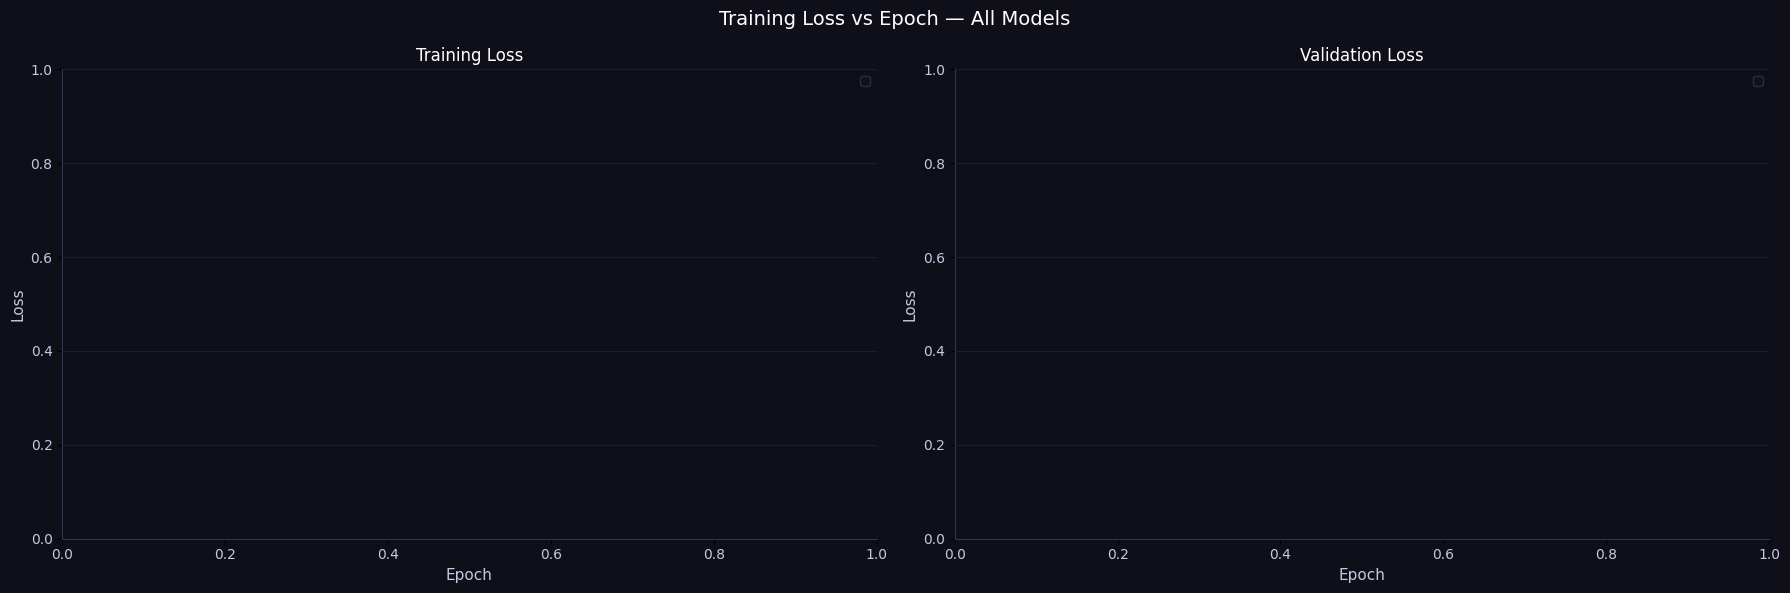

Saved: results/training_loss_curves.png


In [16]:
import wandb
import matplotlib.pyplot as plt

BG = '#0f0f1a'

api = wandb.Api()
run = api.run("st125989-asian-institute-of-technology/llamafactory/v7qtbk3e")

# All your training run names from WandB llamafactory project
# RUN_IDS = {
#     "0.5B Gold":   "st125989-asian-institute-of-technology/llamafactory/qwen2.5-0.5b-graphrag-gold",
#     "1.5B Gold":   "st125989-asian-institute-of-technology/llamafactory/qwen2.5-1.5b-graphrag-gold",
#     "3B Gold":     "st125989-asian-institute-of-technology/llamafactory/qwen2.5-3b-graphrag-gold",
#     "0.5B Hybrid": "st125989-asian-institute-of-technology/llamafactory/qwen2.5-0.5b-graphrag-hybrid",
#     "1.5B Hybrid": "st125989-asian-institute-of-technology/llamafactory/qwen2.5-1.5b-graphrag-hybrid",
#     "3B Hybrid":   "st125989-asian-institute-of-technology/llamafactory/qwen2.5-3b-graphrag-hybrid",
# }

COLORS = {
    "0.5B Gold":   "#a9e34b",
    "1.5B Gold":   "#74c0fc",
    "3B Gold":     "#339af0",
    "0.5B Hybrid": "#f783ac",
    "1.5B Hybrid": "#cc5de8",
    "3B Hybrid":   "#845ef7",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Training Loss vs Epoch — All Models', color='white', fontsize=14)

for label, run_path in RUN_IDS.items():
    try:
        run = api.run(run_path)
        history = run.history(keys=["train/loss", "eval/loss", "epoch"])

        epochs_train = history["epoch"].dropna().tolist()
        loss_train   = history["train/loss"].dropna().tolist()
        epochs_eval  = history["epoch"].dropna().tolist()
        loss_eval    = history["eval/loss"].dropna().tolist()

        color = COLORS[label]

        if loss_train:
            axes[0].plot(epochs_train[:len(loss_train)], loss_train,
                         label=label, color=color, linewidth=1.5, alpha=0.9)
        if loss_eval:
            axes[1].plot(epochs_eval[:len(loss_eval)], loss_eval,
                         label=label, color=color, linewidth=1.5, alpha=0.9)

        print(f"Loaded: {label}")
    except Exception as e:
        print(f"FAILED: {label} — {e}")

for ax, title in zip(axes, ["Training Loss", "Validation Loss"]):
    ax.set_facecolor(BG)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#333355')
    ax.yaxis.grid(True, color='#1e1e3a', linewidth=0.6)
    ax.set_axisbelow(True)
    ax.yaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.xaxis.set_tick_params(labelcolor='#c8c8e0')
    ax.set_xlabel('Epoch', color='#c8c8e0', fontsize=11)
    ax.set_ylabel('Loss', color='#c8c8e0', fontsize=11)
    ax.set_title(title, color='white', fontsize=12)
    ax.legend(fontsize=9, facecolor='#12121a', edgecolor='#333355', labelcolor='white')

plt.tight_layout()
plt.savefig('results/training_loss_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: results/training_loss_curves.png")